# Nelder-Mead

## Import Relevant Libraries

In [ ]:
from __future__ import division
import random
import math
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from IPython import display
%matplotlib inline
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D

# nelder-mead for multimodal function optimization
from scipy.optimize import minimize

plt.rcParams['figure.figsize'] = [10, 10]

## Define Nelder-Mead function from scratch

In [ ]:
def nelder_mead(f, x_start, bounds=None,
                step=0.1, no_improve_thr=10e-6,
                no_improv_break=10, max_iter=0,
                alpha=1., gamma=2., rho=-0.5, sigma=0.5):
    # init
    dim = len(x_start)
    prev_best = f(x_start)
    no_improv = 0
    x_start = x_start.reshape(1, -1)
    X_array = x_start
    res = np.array( [prev_best] )

    # only in one dimention take the step
    for i in range(dim):
        x = np.copy(x_start)
        x[0, i] = x[0, i] + step
        score = f(x[0, :])
        X_array = np.append(X_array, x, axis = 0)
        res = np.append(res, [score], axis = 0)

    # simplex iter
    iters = 0
    while 1:
        # order
        idx = np.argsort(res)
        res = res[idx]
        X_array = X_array[idx]
        best = res[0]

        # break after max_iter
        if max_iter and iters >= max_iter:
            return X_array[0], res[0]
        iters += 1

        # break after no_improv_break iterations with no improvement
        print('...best so far:', best)
        if dim == 2:
            plotCurrentSolution(bounds, X_array[0, :])

        # if there is improvement keep that score as prev_best
        if best < prev_best - no_improve_thr:
            no_improv = 0
            prev_best = best
        else:
            no_improv += 1

        if no_improv >= no_improv_break:
            return X_array[0], res[0]

        # centroid
        x0 = np.zeros_like(x_start)
        for tup in X_array[:-1, :]:
            for i, c in enumerate(tup):
                x0[0, i] += c / (len(res)-1)

        # reflection
        xr = x0 + alpha*(x0 - X_array[-1, :])
        rscore = f(xr[0, :])
        if res[0] <= rscore < res[-2]:
            res = res[0:-1]
            X_array = X_array[0:-1, :]
            X_array = np.append(X_array, xr, axis = 0)
            res = np.append(res, [rscore], axis = 0)
            continue

        # expansion
        if rscore < res[0]:
            xe = x0 + gamma*(x0 - X_array[-1, :])
            escore = f(xe[0, :])
            if escore < rscore:
                res = res[0:-1]
                X_array = X_array[0:-1, :]
                X_array = np.append(X_array, xe, axis = 0)
                res = np.append(res, [escore], axis = 0)
                continue
            else:
                res = res[0:-1]
                X_array = X_array[0:-1, :]
                X_array = np.append(X_array, xr, axis = 0)
                res = np.append(res, [rscore], axis = 0)
                continue

        # contraction
        xc = x0 + rho*(x0 - X_array[-1, :])
        cscore = f(xc[0, :])
        if cscore < res[-1]:
            res = res[0:-1]
            X_array = X_array[0:-1, :]
            X_array = np.append(X_array, xc, axis = 0)
            res = np.append(res, [cscore], axis = 0)
            continue

        # reduction
        x1 = X_array[0, :]
        nres = []
        for count, value in enumerate(X_array):
            x_new = x1 + sigma*(value - x1)
            score = f(x_new)
            X_array[count, :] = x_new
            res[count] = score



Define auxiliary function for plotting

TODO: connect to the Nelder Mead Function

In [ ]:
def plotCurrentSolution(bounds, bestSolution):
    ax = plt.axes(projection='3d')
    # sample input range uniformly at 0.1 increments
    X = np.arange(bounds[0,0], bounds[0,1], 0.1)
    Y = np.arange(bounds[1,0], bounds[1,1], 0.1)
    X, Y = np.meshgrid(X, Y)
    Z = np.zeros_like(X)
    for i in range(len(X)):
        xy = np.array([X[i], Y[i]])
        Z[i] = objective(xy)
    # Plot the surface.
    #surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm, linewidth=0, antialiased=False)
    ax.contour3D(X, Y, Z, 50, cmap='plasma')
    # plot the sample as black circles
    x, y, z = bestSolution[0], bestSolution[1], objective(bestSolution)
    print(x, y, z)
    ax.scatter3D(x, y, z, color='red', s=100)
    ax.view_init(60, 35)
    #plt.draw()
    # plt.show()
    display.display(plt.gcf())
    display.clear_output(wait=True)
    plt.pause(0.1)


## The First Objective Function

#### Define the First Objective Function

In [ ]:
def objective(x):
    return np.sin(x[0]) * np.cos(x[1]) * (1. / (abs(x[2]) + 1))

#### Run the method

In [ ]:
X, y = nelder_mead(objective, np.array([0., 0., 0.]), max_iter=100)
print( X, y )

...best so far: 0.0
...best so far: 0.0
...best so far: 0.0
...best so far: 0.0
...best so far: 0.0
...best so far: 0.0
...best so far: 0.0
...best so far: 0.0
...best so far: 0.0
...best so far: 0.0
[0. 0. 0.] 0.0


## Define the Second Objective Function

### Define Objective Function

Use the **Ackley function** is an example of the latter. It is a two-dimensional objective function that has a global optima at [0,0] but has many local optima.

$f(x_0 \cdots x_n) = -20 exp(-0.2 \sqrt{\frac{1}{n} \sum_{i=1}^n x_i^2}) - exp(\frac{1}{n} \sum_{i=1}^n cos(2\pi x_i)) + 20 + e$

$-32 \leq x_i \leq 32$

$\text{minimum at }f(0, \cdots, 0) = 0$

In [ ]:
# objective function
def objective(bestSolution):
    x, y = bestSolution[0], bestSolution[1]
    fxy = -20.0 * np.exp(-0.2 * np.sqrt(0.5 * (x**2 + y**2)))  \
    - np.exp(0.5 * (np.cos(2 * np.pi * x) + np.cos(2 * np.pi * y))) + np.e + 20
    return fxy


Define range for input

In [ ]:
r_min, r_max = -5.0, 5.0

Plot the Objective Function

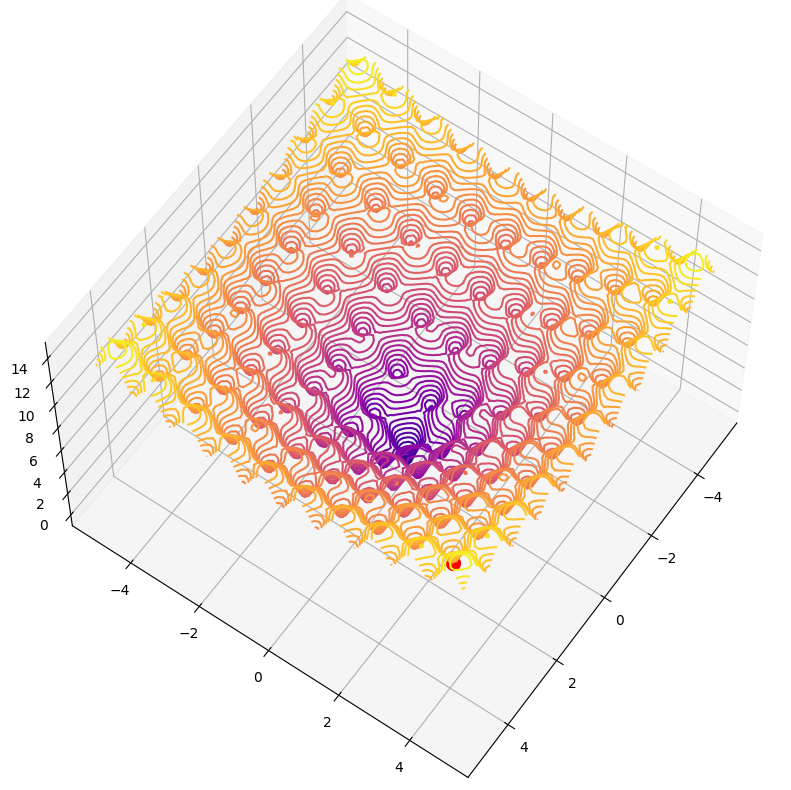

In [ ]:
bounds = np.array( [[r_min, r_max], [r_min, r_max]] )
best_solution = np.array( [4, 4] )
plotCurrentSolution(bounds, best_solution)

### Run the method

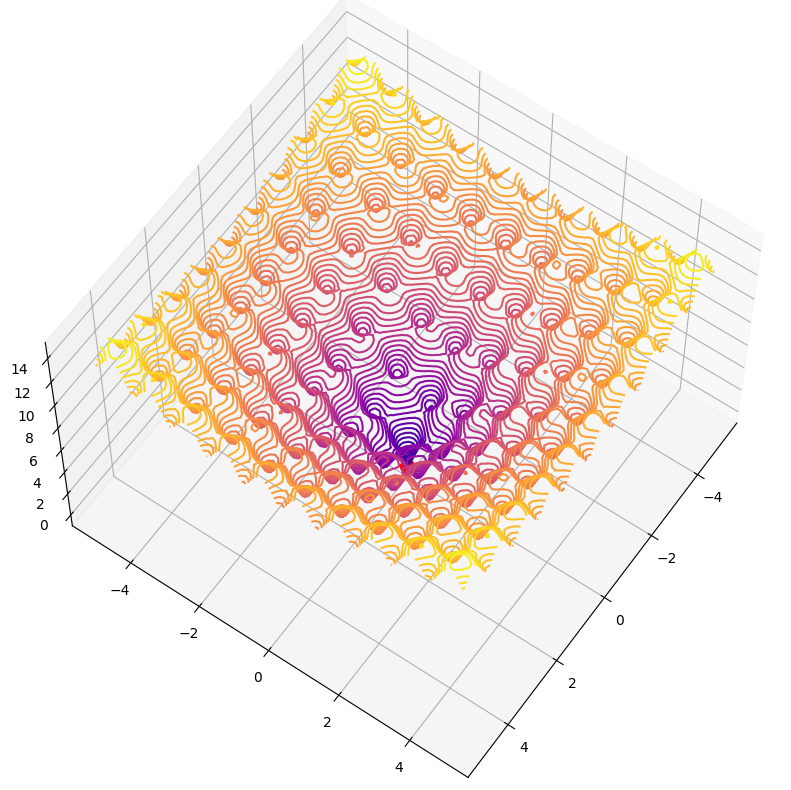

[0. 0.] 0.0


In [ ]:
bounds = np.array( [[r_min, r_max], [r_min, r_max]] )
X, y = nelder_mead(objective, np.array([5., 3.]), bounds, step = 1., max_iter=100)
print( X, y )